In [1]:
!pip install geopy

In [2]:
!pip install pymc arviz

In [3]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd

In [4]:
df_sorted = pd.read_excel('data/raw/FINAL_WIDE_W.xlsx')
df_sorted

,country,year,GDP,inbound,Political Stability,exchange rate,Airtran,politunesco,Rule of Law: Estimate,unesco
0,Azerbaijan,2002,8.79,13.63,-1.19,-0.03,13.26,-5.93,-0.96,5.0
1,Azerbaijan,2003,8.88,13.85,-0.95,-0.02,13.44,-4.74,-0.88,5.0
2,Azerbaijan,2004,8.96,14.06,-1.06,-0.02,13.82,-5.30,-0.90,5.0
3,Azerbaijan,2005,9.20,13.98,-1.12,-0.06,13.94,-5.62,-0.79,5.0
4,Azerbaijan,2006,9.49,13.99,-1.09,-0.11,14.04,-5.46,-0.89,5.0
...,...,...,...,...,...,...,...,...,...,...
193,Türkiye,2015,10.16,17.53,-1.50,1.00,18.39,-11.96,-0.23,8.0
194,Türkiye,2016,10.18,17.25,-2.01,1.11,18.42,-16.06,-0.34,8.0
195,Türkiye,2017,10.23,17.45,-1.79,1.29,18.50,-14.29,-0.32,8.0
196,Türkiye,2018,10.25,17.65,-1.32,1.57,18.57,-10.52,-0.39,8.0


In [10]:
cities = {
    'Azerbaijan': (40.4093, 49.8671),     # Baku
    'China': (34.3416, 108.9398),         # Xi'an
    'Egypt': (31.2001, 29.9187),          # Alexandria
    'Georgia': (42.2679, 42.7180),        # Kutaisi
    'India': (27.0920, 77.6689),          # Fatehpur Sikri
    'Iran': (35.5760, 53.3950),           # Semnan
    'Italy': (45.4408, 12.3155),          # Venice
    'Kazakhstan': (43.2220, 76.8512),     # Almaty
    'Kyrgyzstan': (41.1000, 75.3500),     # Tash Rabat
    'Saudi Arabia': (21.4858, 39.1925),   # Jeddah
    'Türkiye': (40.1828, 29.0666),         # Bursa
}

In [11]:
from geopy.distance import geodesic
import numpy as np

# --- Step 1: Define the list of countries in a consistent order ---
country_list = sorted(cities.keys())
N = len(country_list)

# --- Step 2: Extract geographic coordinates for each country ---
coords = [cities[c] for c in country_list]

# --- Step 3: Construct the distance matrix ---
# Compute pairwise great-circle distances (in kilometers) using geodesic distance
dist_matrix = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        if i != j:
            dist_matrix[i, j] = geodesic(coords[i], coords[j]).kilometers
        else:
            dist_matrix[i, j] = np.inf  # avoid division by zero on the diagonal

# --- Step 4: Construct the inverse-distance weight matrix ---
W_distance_inv = 1 / dist_matrix

# --- Step 5: Row-standardize the matrix (so that each row sums to 1) ---
W_distance_inv = W_distance_inv / W_distance_inv.sum(axis=1, keepdims=True)

# --- Step 6: Store the weight matrix for each year ---
# Since geographic distances are time-invariant, the same matrix is assigned to all years
W_dict = {year: W_distance_inv for year in df_sorted['year'].unique()}



✅ Final step: Run the Bayesian SDM with the inverse-distance weight matrix

In [12]:

# Assume: df_sorted, X, y, W_dict, countries, and years have already been prepared.
# X represents the matrix of independent variables, for example:
X = df_sorted[['GDP', 'Political Stability', 'exchange rate', "Rule of Law: Estimate"]].values

K = X.shape[1]  # Number of independent variables
N = df_sorted.shape[0]  # Total number of data rows (observations)
y = df_sorted['inbound'].values  # Dependent variable

# Map country and year indices
country_to_idx = {c: i for i, c in enumerate(sorted(df_sorted['country'].unique()))}
year_to_idx = {y: i for i, y in enumerate(sorted(df_sorted['year'].unique()))}

N = len(country_to_idx)
T = len(year_to_idx)
K = X.shape[1]

# Construct Wy and WX
y_neighbors = []
WX = np.zeros((N * T, K))

for idx, row in df_sorted.iterrows():
    year = row['year']
    country = row['country']
    c_idx = country_to_idx[country]
    y_idx = year_to_idx[year]
    obs_idx = y_idx * N + c_idx

    # Weight matrix for the current year
    W = W_dict[year]

    # y values for the current year
    y_t = (
        df_sorted[df_sorted['year'] == year]
        .set_index('country')
        .loc[sorted(df_sorted['country'].unique())]['inbound']
        .values
    )

    # Compute Wy
    wy = np.dot(W[c_idx], y_t)
    y_neighbors.append(wy)

    # Compute WX (weighted independent variables)
    X_t = X[y_idx * N:(y_idx + 1) * N]
    WX[obs_idx] = np.dot(W[c_idx], X_t)

y_neighbors = np.array(y_neighbors)

# Country index for fixed effects
country_idx = pd.Categorical(df_sorted['country']).codes

# ✅ Build the Bayesian Spatial Durbin Model (SDM) using PyMC
with pm.Model() as sdm_model:
    # Priors
    beta = pm.Normal("beta", mu=0, sigma=10, shape=K)
    gamma = pm.Normal("gamma", mu=0, sigma=10, shape=K)
    alpha = pm.Normal("alpha", mu=0, sigma=1, shape=N)
    rho = pm.Normal("rho", mu=0, sigma=1)
    sigma = pm.HalfCauchy("sigma", beta=2)

    # Spatial regression equation
    mu = (
        pm.math.dot(X, beta)
        + pm.math.dot(WX, gamma)
        + alpha[country_idx]
        + rho * y_neighbors
    )

    # Likelihood for the dependent variable
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    # Sampling
    trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True)


 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000    0             0.015       511          35.20 draws/s    0:00:56   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━╸   1983    0             0.014       511          17.83 draws/s    0:01:51   0:00:01

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000    0             0.015       511          35.20 draws/s    0:00:56   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━╸   1986    0             0.014       255          17.84 draws/s    0:01:51   0:00:01

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000    0             0.015       511          35.20 draws/s    0:00:56   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━╸   1995    0             0.014       255          17.89 draws/s    0:01:51   0:00:01

✅ Next Step: Summarizing and Visualizing the Results




             mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
rho        0.5550  0.1021  0.3693   0.7432     0.0036   0.0026   829.8668   
beta[0]    0.5297  0.1747  0.2102   0.8609     0.0058   0.0040   913.4461   
beta[1]    0.4249  0.1300  0.1894   0.6708     0.0031   0.0031  1815.7973   
beta[2]    0.1447  0.0813 -0.0169   0.2865     0.0028   0.0019   870.4032   
beta[3]    0.2837  0.1861 -0.0756   0.6239     0.0047   0.0048  1548.6154   
gamma[0]   0.2217  0.0898  0.0614   0.3970     0.0023   0.0020  1575.2900   
gamma[1]   0.0067  0.1511 -0.3033   0.2663     0.0037   0.0032  1687.9976   
gamma[2]   0.0071  0.0353 -0.0630   0.0719     0.0009   0.0008  1478.4283   
gamma[3]   0.0539  0.1717 -0.2458   0.4095     0.0041   0.0041  1737.1758   
sigma      0.3986  0.0217  0.3589   0.4400     0.0005   0.0005  2042.7634   
alpha[0]  -0.8368  0.3792 -1.5458  -0.1372     0.0138   0.0077   760.7406   
alpha[1]   3.2588  0.3271  2.6373   3.8597     0.0122   0.0079   704.4629   

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rho,0.5550,0.1021,0.3693,0.7432,0.0036,0.0026,829.8668,1013.2422,1.0033
beta[0],0.5297,0.1747,0.2102,0.8609,0.0058,0.0040,913.4461,1083.6467,1.0008
beta[1],0.4249,0.1300,0.1894,0.6708,0.0031,0.0031,1815.7973,1592.9783,1.0032
beta[2],0.1447,0.0813,-0.0169,0.2865,0.0028,0.0019,870.4032,1094.8408,1.0025
beta[3],0.2837,0.1861,-0.0756,0.6239,0.0047,0.0048,1548.6154,1272.6881,1.0041
gamma[0],0.2217,0.0898,0.0614,0.3970,0.0023,0.0020,1575.2900,1440.8773,0.9996
gamma[1],0.0067,0.1511,-0.3033,0.2663,0.0037,0.0032,1687.9976,1376.1073,1.0009
gamma[2],0.0071,0.0353,-0.0630,0.0719,0.0009,0.0008,1478.4283,1303.8040,0.9996
gamma[3],0.0539,0.1717,-0.2458,0.4095,0.0041,0.0041,1737.1758,1562.2810,0.9997
sigma,0.3986,0.0217,0.3589,0.4400,0.0005,0.0005,2042.7634,1519.4341,1.0022


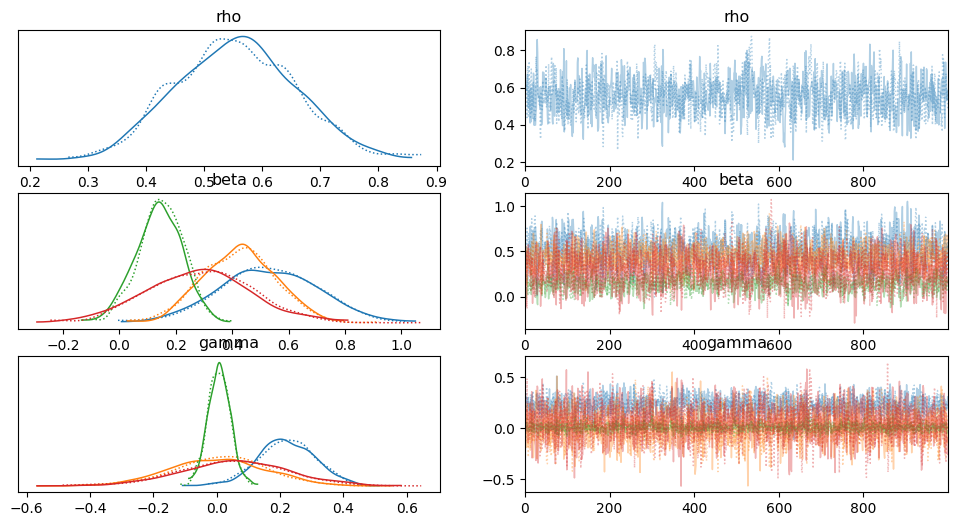

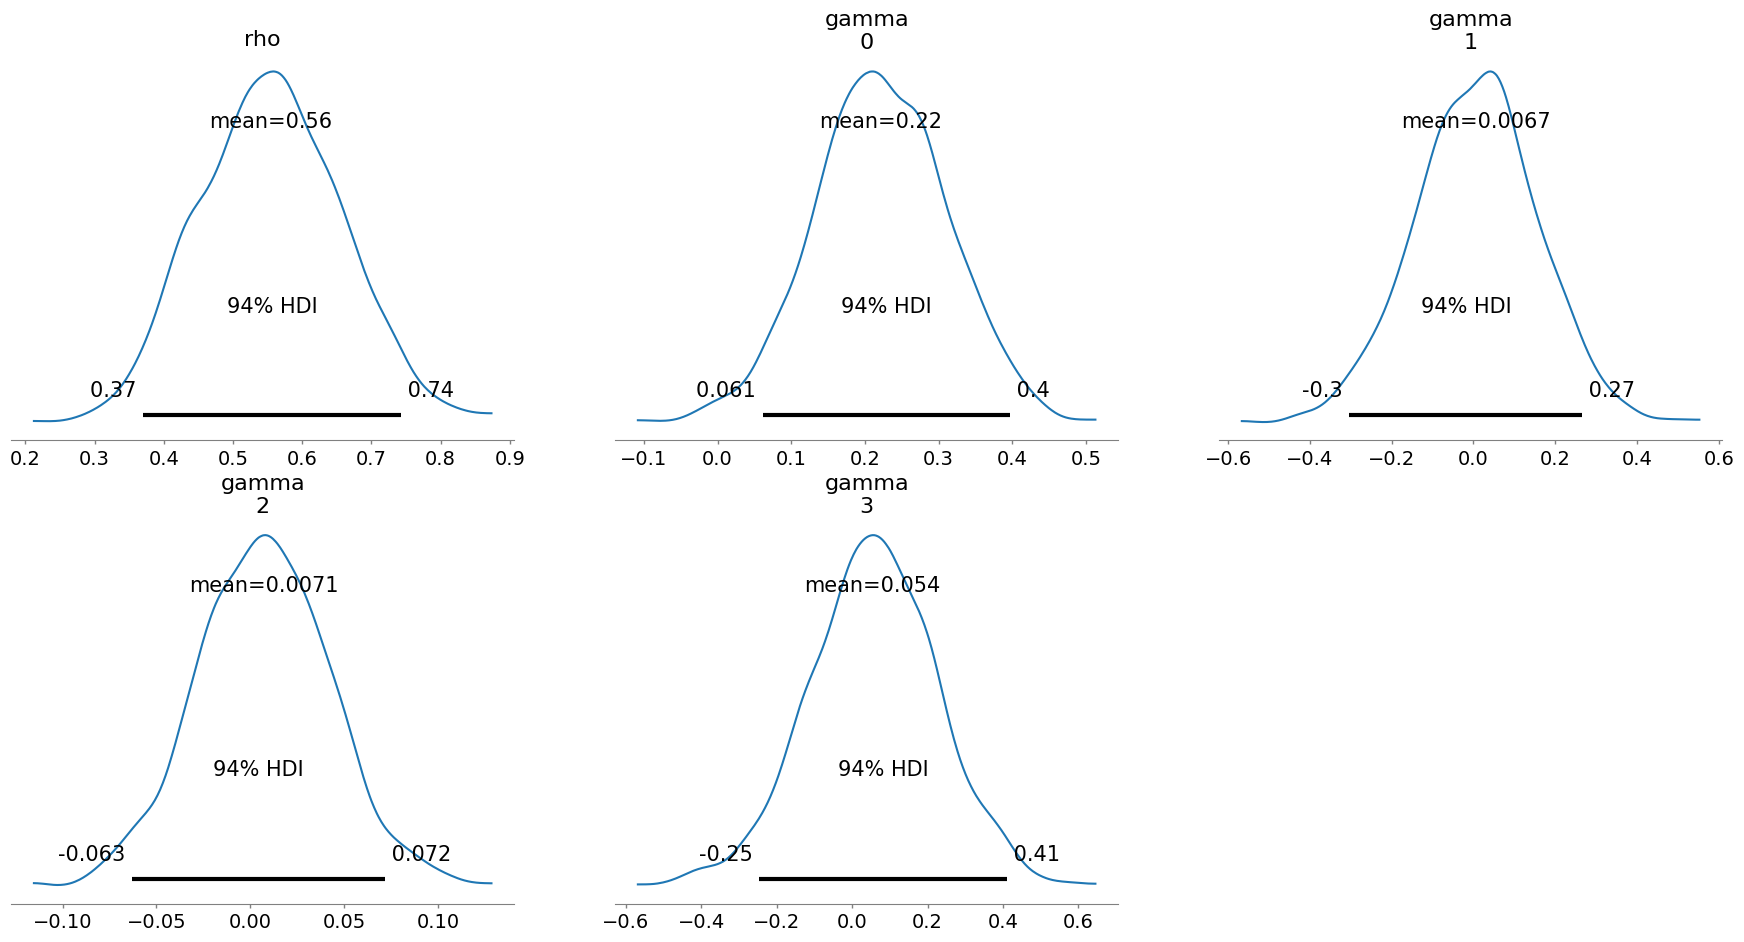

In [13]:
# --- Parameter summary ---
summary = az.summary(trace, var_names=["rho", "beta", "gamma", "sigma", "alpha"], round_to=4)
print(summary)

# --- Diagnostic plots ---
az.plot_trace(trace, var_names=["rho", "beta", "gamma"])
az.plot_posterior(trace, var_names=["rho", "gamma"])

summary

/tmp/ipython-input-3312137701.py:10: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  alpha_hdi = az.hdi(alpha_samples.T, hdi_prob=0.94)  # shape: (N countries, 2)


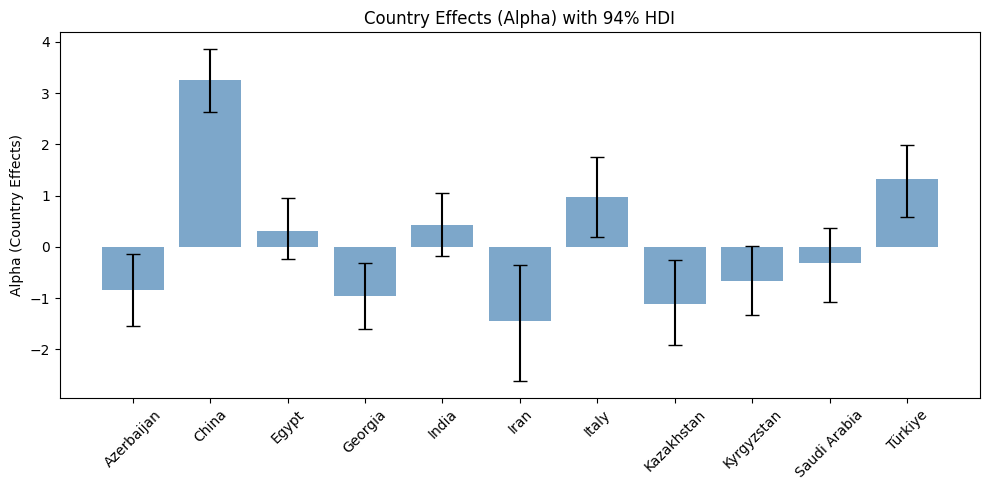

In [14]:
import matplotlib.pyplot as plt
import arviz as az
import numpy as np

# Extract country-level effects (alpha) from the trace
alpha_samples = trace.posterior["alpha"].stack(draws=("chain", "draw")).values  # shape: (N countries, samples)

# Compute mean and HDI (Highest Density Interval)
alpha_means = alpha_samples.mean(axis=1)
alpha_hdi = az.hdi(alpha_samples.T, hdi_prob=0.94)  # shape: (N countries, 2)

# Prepare data for visualization
countries_ordered = sorted(country_to_idx.keys())
lower_bounds = alpha_hdi[:, 0]
upper_bounds = alpha_hdi[:, 1]

# Plot the bar chart with HDI error bars
fig, ax = plt.subplots(figsize=(10, 5))
errors = [alpha_means - lower_bounds, upper_bounds - alpha_means]
ax.bar(countries_ordered, alpha_means, yerr=errors, capsize=5, color='steelblue', alpha=0.7)

# Aesthetic adjustments
ax.set_ylabel("Alpha (Country Effects)")
ax.set_title("Country Effects (Alpha) with 94% HDI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)
plt.show()
